# EconML Tutorial 05: DRLearner And Doubly Robust Estimation

This notebook introduces `DRLearner`, EconML's learner built around doubly robust pseudo-outcomes.

The previous notebooks focused on DML residualization and causal forests. `DRLearner` approaches the same CATE goal from a different angle. It estimates nuisance functions for:

- treatment assignment, usually called the propensity model;
- potential outcomes under treatment and control, usually called outcome regression models.

Then it combines those nuisance estimates into a doubly robust pseudo-outcome. A final model learns CATE by predicting that pseudo-outcome from effect modifiers.

The core causal question stays the same:

> For each unit, how much would the outcome change if treatment were applied instead of not applied?

The new lesson is how doubly robust construction uses both propensity and outcome information to make the estimate less fragile than relying on either one alone.

## Learning Goals

By the end of this notebook, you should be able to:

- explain the doubly robust idea in practical language;
- distinguish propensity nuisance models from outcome-regression nuisance models;
- write and inspect a binary-treatment doubly robust pseudo-outcome;
- understand why propensity clipping is used;
- fit manual DR-style CATE models for teaching;
- fit EconML's `DRLearner` with linear and flexible final models;
- compare DRLearner with a pure outcome-model T-learner baseline;
- evaluate CATE recovery, segment summaries, decile calibration, and targeting behavior;
- describe when DRLearner is a good estimator to try.

## The Doubly Robust Idea

A binary-treatment doubly robust pseudo-outcome combines three nuisance estimates:

- `e(X, W)`: estimated probability of treatment;
- `m1(X, W)`: estimated outcome if treated;
- `m0(X, W)`: estimated outcome if untreated.

For observed outcome `Y` and treatment `T`, the pseudo-outcome is:

`tau_dr = m1 - m0 + T * (Y - m1) / e - (1 - T) * (Y - m0) / (1 - e)`

The first part, `m1 - m0`, is the outcome-model estimate of the treatment effect. The two correction terms use residuals from the observed treatment arm, scaled by inverse propensity. If the outcome models are good, the corrections are small on average. If the propensity model is good, the corrections can repair certain outcome-model errors.

That is the practical meaning of doubly robust: the estimator has two routes to credibility. It is not invincible; it still needs causal identification, overlap, pre-treatment covariates, and reasonable nuisance models.

## Tutorial Flow

The notebook proceeds in four layers:

1. Build a confounded binary-treatment dataset with known CATE.
2. Demonstrate doubly robust ATE logic using oracle and intentionally weak nuisance functions.
3. Manually construct cross-fitted DR pseudo-outcomes and fit a final CATE model.
4. Fit EconML `DRLearner` and compare it with baselines.

The manual layer is included because it makes the EconML estimator much easier to understand. The EconML layer is what you would normally use in practice.

## Setup

This cell imports the packages used in the lesson, creates output folders, fixes a random seed, and checks that EconML is available. The warning filters keep the notebook readable while allowing real execution failures to appear.

In [1]:
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import econml
    from econml.dr import DRLearner
    from econml.dml import LinearDML
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")

EconML available: True
EconML version: 0.16.0
Figures will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/tables


What this shows: the environment is ready if EconML imports successfully. The output folders are shared across this tutorial series, and this notebook writes files with the `05_` prefix.

## Where DRLearner Fits

The next table positions `DRLearner` against the estimators already covered. This helps explain why we need another learner after DML and causal forests.

In [2]:
estimator_map = pd.DataFrame(
    [
        {
            "estimator": "LinearDML",
            "main construction": "Residualize outcome and treatment, then fit a final CATE model",
            "best use": "Readable linear CATE models after DML adjustment",
            "main diagnostic focus": "Residualized signal, coefficients, CATE recovery",
        },
        {
            "estimator": "CausalForestDML",
            "main construction": "DML adjustment with a forest final CATE model",
            "best use": "Nonlinear heterogeneity and treatment targeting",
            "main diagnostic focus": "Feature importance, intervals, slices, support",
        },
        {
            "estimator": "DRLearner",
            "main construction": "Doubly robust pseudo-outcome from outcome and propensity models",
            "best use": "Binary treatment CATE with explicit outcome and propensity nuisance modeling",
            "main diagnostic focus": "Propensity overlap, outcome models by arm, pseudo-outcome noise, final CATE model",
        },
    ]
)

estimator_map.to_csv(TABLE_DIR / "05_estimator_map.csv", index=False)
display(estimator_map)

,estimator,main construction,best use,main diagnostic focus
0,LinearDML,"Residualize outcome and treatment, then fit a ...",Readable linear CATE models after DML adjustment,"Residualized signal, coefficients, CATE recovery"
1,CausalForestDML,DML adjustment with a forest final CATE model,Nonlinear heterogeneity and treatment targeting,"Feature importance, intervals, slices, support"
2,DRLearner,Doubly robust pseudo-outcome from outcome and ...,Binary treatment CATE with explicit outcome an...,"Propensity overlap, outcome models by arm, pse..."


What this shows: `DRLearner` is not just another black-box CATE model. Its key object is a pseudo-outcome that combines outcome-regression and inverse-propensity correction.

## Synthetic Teaching Data

The next cell creates a binary-treatment observational dataset. The true treatment effect is nonlinear but not wildly complex, so a flexible final model can learn it while a linear final model still provides a useful baseline.

The simulation includes:

- observed confounding through treatment assignment;
- separate potential-outcome means under treatment and control;
- true CATE for teaching evaluation;
- oracle propensity and potential-outcome means for a short double-robustness demonstration.

In [3]:
n = 3_200

baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = 0.50 * baseline_need - 0.25 * prior_engagement + rng.normal(0, 0.85, size=n)
content_affinity = 0.35 * prior_engagement + rng.normal(0, 0.95, size=n)
price_sensitivity = rng.normal(0, 1, size=n)
trust_score = rng.normal(0, 1, size=n)
recency_gap = rng.normal(0, 1, size=n)
region_risk = rng.binomial(1, 0.35, size=n)
high_need_segment = (baseline_need > 0.55).astype(int)

account_tenure = rng.normal(0, 1, size=n)
seasonality_index = rng.normal(0, 1, size=n)
device_stability = rng.normal(0, 1, size=n)
traffic_intensity = rng.normal(0, 1, size=n)

propensity_logit = (
    -0.18
    + 0.78 * baseline_need
    + 0.42 * prior_engagement
    + 0.40 * friction_score
    + 0.28 * content_affinity
    - 0.20 * trust_score
    + 0.24 * region_risk
    + 0.22 * high_need_segment
    - 0.30 * account_tenure
    + 0.24 * seasonality_index
    + 0.18 * traffic_intensity
)
propensity = 1 / (1 + np.exp(-propensity_logit))
propensity = np.clip(propensity, 0.035, 0.965)
treatment = rng.binomial(1, propensity, size=n)

true_cate = (
    0.38
    + 0.30 * high_need_segment
    + 0.22 * np.tanh(prior_engagement)
    - 0.24 * np.maximum(friction_score, 0)
    + 0.16 * content_affinity
    - 0.16 * region_risk
    - 0.12 * (price_sensitivity > 0.8).astype(float)
)

mu0 = (
    2.10
    + 0.80 * baseline_need
    + 0.62 * prior_engagement
    - 0.50 * friction_score
    + 0.30 * content_affinity
    + 0.22 * trust_score
    + 0.34 * account_tenure
    + 0.24 * seasonality_index
    + 0.18 * device_stability
    + 0.18 * traffic_intensity
    + 0.16 * region_risk
    + 0.12 * baseline_need * friction_score
)
mu1 = mu0 + true_cate
noise = rng.normal(0, 0.90, size=n)
outcome = np.where(treatment == 1, mu1, mu0) + noise

teaching_df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "trust_score": trust_score,
        "recency_gap": recency_gap,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "account_tenure": account_tenure,
        "seasonality_index": seasonality_index,
        "device_stability": device_stability,
        "traffic_intensity": traffic_intensity,
        "propensity": propensity,
        "treatment": treatment,
        "outcome": outcome,
        "mu0": mu0,
        "mu1": mu1,
        "true_cate": true_cate,
    }
)

teaching_df.head()

,user_id,baseline_need,prior_engagement,friction_score,content_affinity,price_sensitivity,trust_score,recency_gap,region_risk,high_need_segment,account_tenure,seasonality_index,device_stability,traffic_intensity,propensity,treatment,outcome,mu0,mu1,true_cate
0,0,-0.7931,-1.2901,-0.3328,-0.0911,-1.1530,-1.3164,-0.7477,1,0,-3.0473,-0.3020,-0.9402,2.2139,0.5608,1,-0.9533,-0.1725,-0.1561,0.0164
1,1,0.2406,0.2599,-0.4755,0.3089,-0.9692,1.3240,-0.4711,0,0,-0.5008,-0.4229,1.2210,0.6131,0.4769,1,4.0504,3.1199,3.6053,0.4853
2,2,-1.8963,-0.3197,-0.8976,-0.2012,-1.2255,-0.4610,0.0474,0,0,-0.0048,-0.8700,-1.7494,-0.0209,0.0889,0,2.6691,0.3469,0.6267,0.2798
3,3,1.3958,-0.2729,0.3052,0.4511,0.6809,-1.5277,1.4382,0,1,1.0852,-0.2230,-2.3089,0.9227,0.7949,1,4.4769,2.8111,3.4315,0.6203
4,4,0.6383,-1.4263,0.6617,-1.9380,0.5773,1.1598,2.8067,0,1,-1.8344,-0.9164,-0.2073,-0.3209,0.4259,0,-0.0188,0.1812,0.1963,0.0151


What this shows: `treatment` and `outcome` are the fields we would observe in real data. `propensity`, `mu0`, `mu1`, and `true_cate` are oracle fields used only for teaching and evaluation.

## Field Dictionary

This table names the model role of each column. The most important point is that oracle fields are never allowed into fitted models.

In [4]:
effect_modifier_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "trust_score",
    "recency_gap",
    "region_risk",
    "high_need_segment",
]
control_cols = ["account_tenure", "seasonality_index", "device_stability", "traffic_intensity"]
all_observed_covariates = effect_modifier_cols + control_cols
true_driver_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "region_risk",
    "high_need_segment",
]

field_rows = []
for col in effect_modifier_cols:
    field_rows.append(
        {
            "column": col,
            "role": "X effect modifier",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature used by final CATE models.",
            "true_cate_driver": "yes" if col in true_driver_cols else "no",
        }
    )
for col in control_cols:
    field_rows.append(
        {
            "column": col,
            "role": "W control",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment adjustment feature used by nuisance models.",
            "true_cate_driver": "no",
        }
    )
for col, role, description in [
    ("treatment", "treatment", "Binary intervention indicator."),
    ("outcome", "outcome", "Observed post-treatment outcome."),
    ("propensity", "oracle", "True treatment probability from the simulated assignment process."),
    ("mu0", "oracle", "True conditional mean outcome under control."),
    ("mu1", "oracle", "True conditional mean outcome under treatment."),
    ("true_cate", "oracle", "Known individual treatment effect used only for tutorial grading."),
]:
    field_rows.append(
        {
            "column": col,
            "role": role,
            "observed_in_real_analysis": "yes" if role in ["treatment", "outcome"] else "no",
            "description": description,
            "true_cate_driver": "not applicable",
        }
    )

field_dictionary = pd.DataFrame(field_rows)
field_dictionary.to_csv(TABLE_DIR / "05_field_dictionary.csv", index=False)
display(field_dictionary)

,column,role,observed_in_real_analysis,description,true_cate_driver
0,baseline_need,X effect modifier,yes,Pre-treatment feature used by final CATE models.,yes
1,prior_engagement,X effect modifier,yes,Pre-treatment feature used by final CATE models.,yes
2,friction_score,X effect modifier,yes,Pre-treatment feature used by final CATE models.,yes
3,content_affinity,X effect modifier,yes,Pre-treatment feature used by final CATE models.,yes
4,price_sensitivity,X effect modifier,yes,Pre-treatment feature used by final CATE models.,yes
5,trust_score,X effect modifier,yes,Pre-treatment feature used by final CATE models.,no
6,recency_gap,X effect modifier,yes,Pre-treatment feature used by final CATE models.,no
7,region_risk,X effect modifier,yes,Pre-treatment feature used by final CATE models.,yes
8,high_need_segment,X effect modifier,yes,Pre-treatment feature used by final CATE models.,yes
9,account_tenure,W control,yes,Pre-treatment adjustment feature used by nuisa...,no


What this shows: DRLearner needs both `X` and `W` roles. The final CATE model uses `X`, while nuisance models use both `X` and `W` to estimate outcomes and propensity.

## Basic Shape And True Effect Scale

This summary checks the sample size, treatment rate, and true CATE distribution before any estimation.

In [5]:
basic_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(teaching_df)},
        {"metric": "columns", "value": teaching_df.shape[1]},
        {"metric": "X_effect_modifiers", "value": len(effect_modifier_cols)},
        {"metric": "W_controls", "value": len(control_cols)},
        {"metric": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"metric": "outcome_mean", "value": teaching_df["outcome"].mean()},
        {"metric": "true_ate", "value": teaching_df["true_cate"].mean()},
        {"metric": "true_cate_std", "value": teaching_df["true_cate"].std()},
        {"metric": "true_cate_min", "value": teaching_df["true_cate"].min()},
        {"metric": "true_cate_max", "value": teaching_df["true_cate"].max()},
    ]
)

basic_summary.to_csv(TABLE_DIR / "05_basic_summary.csv", index=False)
display(basic_summary)

,metric,value
0,rows,"3,200.0000"
1,columns,20.0000
2,X_effect_modifiers,9.0000
3,W_controls,4.0000
4,treatment_rate,0.4872
5,outcome_mean,2.3877
6,true_ate,0.2988
7,true_cate_std,0.3266
8,true_cate_min,-0.8828
9,true_cate_max,1.3267


What this shows: the treatment rate is usable and the CATE distribution has real spread. That makes the dataset appropriate for learning heterogeneous effects rather than only one average effect.

## True CATE Distribution

This plot shows the effect heterogeneity that the learners are trying to recover. In real data, this plot would not be available.

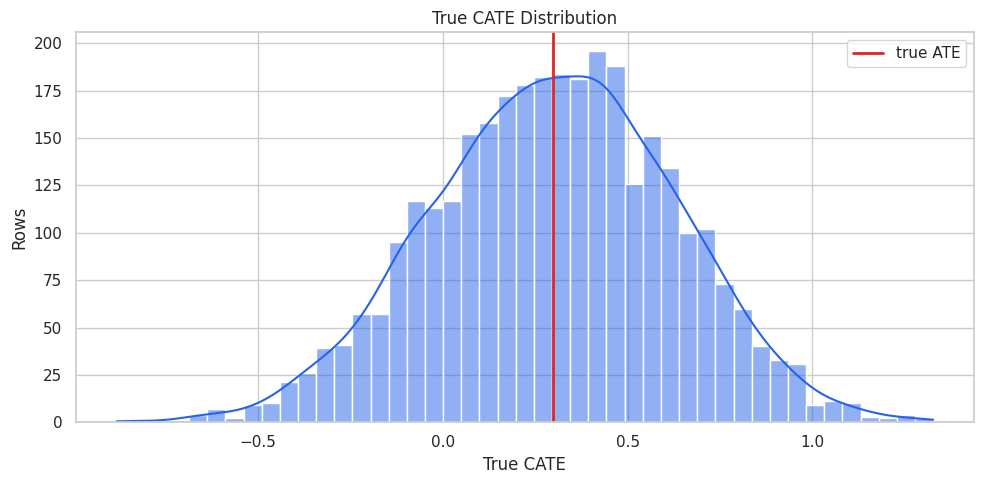

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(teaching_df["true_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(teaching_df["true_cate"].mean(), color="#dc2626", linewidth=2, label="true ATE")
ax.set_title("True CATE Distribution")
ax.set_xlabel("True CATE")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: average treatment effect is only one slice of the problem. The distribution shows why a CATE learner can be useful for ranking and targeting.

## Raw Treated-Versus-Control Difference

A raw outcome difference ignores confounding. This cell shows the raw contrast and compares it with the true ATE.

In [7]:
raw_group_summary = (
    teaching_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        observed_outcome_mean=("outcome", "mean"),
        true_cate_mean=("true_cate", "mean"),
        propensity_mean=("propensity", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        friction_score_mean=("friction_score", "mean"),
        content_affinity_mean=("content_affinity", "mean"),
    )
    .reset_index()
)
raw_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"].eq(1), "observed_outcome_mean"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"].eq(0), "observed_outcome_mean"].iloc[0]
)
true_ate = teaching_df["true_cate"].mean()

raw_difference_summary = pd.DataFrame(
    [
        {"quantity": "raw treated minus untreated outcome mean", "value": raw_difference},
        {"quantity": "true ATE", "value": true_ate},
        {"quantity": "raw difference minus true ATE", "value": raw_difference - true_ate},
    ]
)

raw_group_summary.to_csv(TABLE_DIR / "05_raw_group_summary.csv", index=False)
raw_difference_summary.to_csv(TABLE_DIR / "05_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_summary)

,treatment,rows,observed_outcome_mean,true_cate_mean,propensity_mean,baseline_need_mean,friction_score_mean,content_affinity_mean
0,0,1641,1.9107,0.2501,0.3583,-0.4347,-0.3087,-0.1290
1,1,1559,2.8899,0.3500,0.6201,0.3913,0.2577,0.1506


,quantity,value
0,raw treated minus untreated outcome mean,0.9791
1,true ATE,0.2988
2,raw difference minus true ATE,0.6803


What this shows: the raw comparison is contaminated by who gets treated. DRLearner addresses this by using propensity and outcome nuisance models rather than relying on raw group means.

## Covariate Balance Table

Standardized mean differences show which pre-treatment covariates differ between treated and untreated rows.

In [8]:
balance_rows = []
for col in all_observed_covariates:
    treated_values = teaching_df.loc[teaching_df["treatment"].eq(1), col]
    control_values = teaching_df.loc[teaching_df["treatment"].eq(0), col]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_difference": (treated_values.mean() - control_values.mean()) / pooled_sd,
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=lambda s: s.abs(), ascending=False)
balance_table.to_csv(TABLE_DIR / "05_covariate_balance.csv", index=False)
display(balance_table)

,covariate,treated_mean,control_mean,standardized_difference
0,baseline_need,0.3913,-0.4347,0.8981
8,high_need_segment,0.4400,0.1426,0.6925
2,friction_score,0.2577,-0.3087,0.5763
1,prior_engagement,0.1881,-0.1191,0.3087
3,content_affinity,0.1506,-0.1290,0.2750
10,seasonality_index,0.1067,-0.1393,0.2519
9,account_tenure,-0.1262,0.1140,-0.2392
12,traffic_intensity,0.0874,-0.0937,0.1852
5,trust_score,-0.0697,0.1080,-0.1765
7,region_risk,0.3554,0.3126,0.0907


What this shows: treatment assignment is clearly related to observed covariates. The doubly robust workflow needs these covariates in the nuisance models to reduce confounding.

## Covariate Balance Plot

The plot highlights the most imbalanced features. These are the variables most visibly tied to treatment assignment.

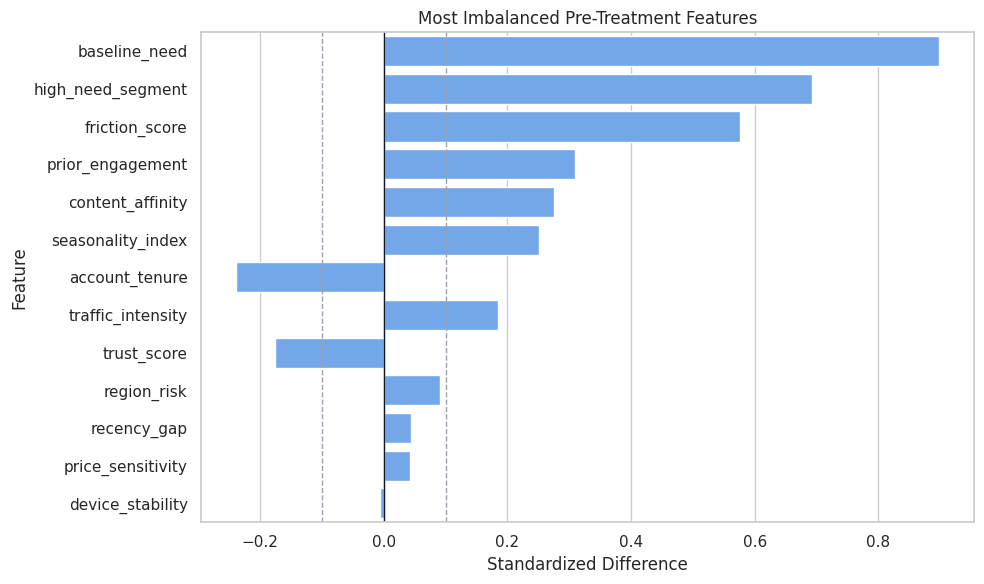

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=balance_table.head(13),
    x="standardized_difference",
    y="covariate",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.axvline(-0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Most Imbalanced Pre-Treatment Features")
ax.set_xlabel("Standardized Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: imbalance is not a failure of the tutorial data; it is the reason we need causal adjustment. The model should not be trusted without this kind of design check.

## Propensity Overlap

Doubly robust estimators use inverse propensity terms, so overlap matters a lot. If propensities are close to zero or one, correction terms can become unstable.

In [10]:
propensity_summary = (
    teaching_df.assign(propensity_bucket=pd.cut(teaching_df["propensity"], bins=np.linspace(0, 1, 11), include_lowest=True))
    .groupby("propensity_bucket", observed=True)
    .agg(
        rows=("propensity", "size"),
        treatment_rate=("treatment", "mean"),
        true_cate_mean=("true_cate", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
    )
    .reset_index()
)
propensity_summary["propensity_bucket"] = propensity_summary["propensity_bucket"].astype(str)
propensity_summary.to_csv(TABLE_DIR / "05_propensity_bucket_summary.csv", index=False)
display(propensity_summary)

,propensity_bucket,rows,treatment_rate,true_cate_mean,baseline_need_mean
0,"(-0.001, 0.1]",167,0.0719,0.1040,-1.6629
1,"(0.1, 0.2]",357,0.1569,0.1620,-1.0558
2,"(0.2, 0.3]",373,0.2466,0.2197,-0.6585
3,"(0.3, 0.4]",400,0.3275,0.2521,-0.4154
4,"(0.4, 0.5]",376,0.4468,0.2572,-0.1286
5,"(0.5, 0.6]",398,0.5201,0.2981,0.1670
6,"(0.6, 0.7]",351,0.6895,0.3809,0.4030
7,"(0.7, 0.8]",329,0.7751,0.3789,0.7143
8,"(0.8, 0.9]",303,0.8581,0.4839,1.1202
9,"(0.9, 1.0]",146,0.9315,0.5331,1.5689


What this shows: treatment probability varies substantially, but most rows remain away from the most extreme buckets. That makes the inverse-propensity correction usable for teaching.

## Propensity Overlap Plot

The histogram shows true propensity by treatment group. In real data, this plot would use estimated propensity scores.

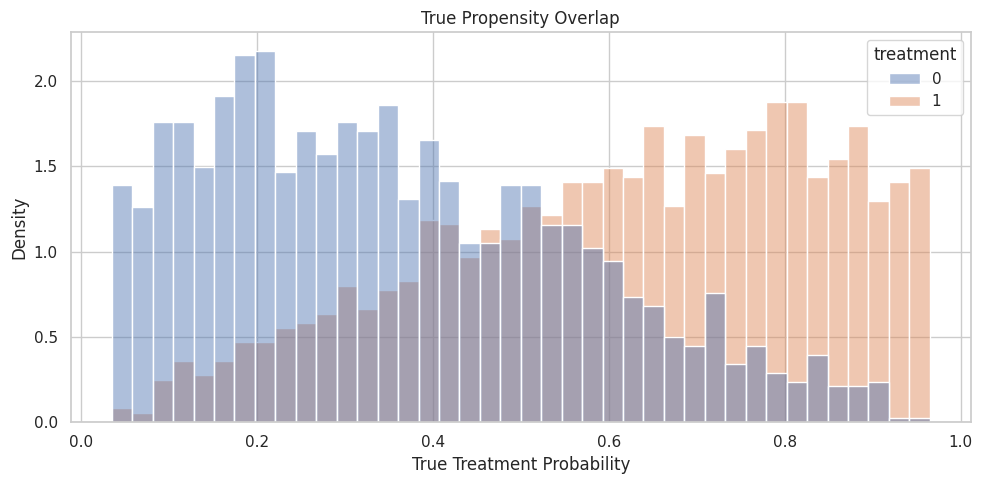

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("True Propensity Overlap")
ax.set_xlabel("True Treatment Probability")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the treated and untreated distributions overlap, but they are shifted. This is exactly the kind of setting where propensity-aware correction is useful.

## Oracle Doubly Robust ATE Demonstration

Before fitting models, we use oracle simulation fields to show the algebraic idea behind double robustness.

The four nuisance settings below are artificial:

- oracle outcome models and oracle propensity;
- oracle outcome models with weak propensity;
- weak outcome models with oracle propensity;
- weak outcome models with weak propensity.

The point is not that real analyses have oracle nuisance functions. The point is to see why using both outcome and propensity information can be safer than relying on only one route.

In [12]:
def dr_pseudo_outcome(y, t, mu0_hat, mu1_hat, propensity_hat, min_propensity=0.03):
    e = np.clip(propensity_hat, min_propensity, 1 - min_propensity)
    return mu1_hat - mu0_hat + t * (y - mu1_hat) / e - (1 - t) * (y - mu0_hat) / (1 - e)

Y = teaching_df["outcome"].to_numpy()
T = teaching_df["treatment"].to_numpy()
mu0_oracle = teaching_df["mu0"].to_numpy()
mu1_oracle = teaching_df["mu1"].to_numpy()
e_oracle = teaching_df["propensity"].to_numpy()

mu0_weak = np.full(len(teaching_df), teaching_df.loc[teaching_df["treatment"].eq(0), "outcome"].mean())
mu1_weak = np.full(len(teaching_df), teaching_df.loc[teaching_df["treatment"].eq(1), "outcome"].mean())
e_weak = np.full(len(teaching_df), teaching_df["treatment"].mean())

oracle_demo_rows = []
for label, mu0_hat, mu1_hat, e_hat in [
    ("oracle outcome + oracle propensity", mu0_oracle, mu1_oracle, e_oracle),
    ("oracle outcome + weak propensity", mu0_oracle, mu1_oracle, e_weak),
    ("weak outcome + oracle propensity", mu0_weak, mu1_weak, e_oracle),
    ("weak outcome + weak propensity", mu0_weak, mu1_weak, e_weak),
    ("raw treated-control difference", None, None, None),
]:
    if label == "raw treated-control difference":
        estimate = raw_difference
    else:
        estimate = dr_pseudo_outcome(Y, T, mu0_hat, mu1_hat, e_hat).mean()
    oracle_demo_rows.append(
        {
            "nuisance_setting": label,
            "ate_estimate": estimate,
            "true_ate": true_ate,
            "estimate_minus_true_ate": estimate - true_ate,
        }
    )

oracle_dr_demo = pd.DataFrame(oracle_demo_rows)
oracle_dr_demo.to_csv(TABLE_DIR / "05_oracle_dr_ate_demo.csv", index=False)
display(oracle_dr_demo)

,nuisance_setting,ate_estimate,true_ate,estimate_minus_true_ate
0,oracle outcome + oracle propensity,0.2910,0.2988,-0.0078
1,oracle outcome + weak propensity,0.3062,0.2988,0.0074
2,weak outcome + oracle propensity,0.3249,0.2988,0.0261
3,weak outcome + weak propensity,0.9791,0.2988,0.6803
4,raw treated-control difference,0.9791,0.2988,0.6803


What this shows: when either the outcome route or the propensity route is strong, the doubly robust estimate can stay close to the truth. When both routes are weak, the estimate can fail badly.

## Train And Test Split

The train set is used for nuisance and CATE model fitting. The test set is held out for evaluating CATE recovery against known truth.

In [13]:
train_idx, test_idx = train_test_split(
    teaching_df.index,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df["treatment"],
)

train_df = teaching_df.loc[train_idx].reset_index(drop=True)
test_df = teaching_df.loc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "treatment_rate": train_df["treatment"].mean(), "true_ate": train_df["true_cate"].mean()},
        {"split": "test", "rows": len(test_df), "treatment_rate": test_df["treatment"].mean(), "true_ate": test_df["true_cate"].mean()},
    ]
)

split_summary.to_csv(TABLE_DIR / "05_train_test_split_summary.csv", index=False)
display(split_summary)

,split,rows,treatment_rate,true_ate
0,train,2080,0.4870,0.3044
1,test,1120,0.4875,0.2884


What this shows: the train and test splits have similar treatment rates and true ATEs. That makes downstream model comparisons easier to read.

## Modeling Matrices

This cell creates the arrays and data frames used by manual DR construction and EconML. Oracle fields stay out of all model inputs.

In [14]:
Y_train = train_df["outcome"].to_numpy()
T_train = train_df["treatment"].to_numpy()
Y_test = test_df["outcome"].to_numpy()
T_test = test_df["treatment"].to_numpy()

X_train = train_df[effect_modifier_cols]
X_test = test_df[effect_modifier_cols]
W_train = train_df[control_cols]
W_test = test_df[control_cols]

nuisance_train = train_df[all_observed_covariates]
nuisance_test = test_df[all_observed_covariates]
true_cate_train = train_df["true_cate"].to_numpy()
true_cate_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    [
        {"object": "Y_train", "rows": Y_train.shape[0], "columns": 1, "meaning": "Observed outcome."},
        {"object": "T_train", "rows": T_train.shape[0], "columns": 1, "meaning": "Observed binary treatment."},
        {"object": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1], "meaning": "Effect modifiers used by final CATE models."},
        {"object": "W_train", "rows": W_train.shape[0], "columns": W_train.shape[1], "meaning": "Controls used by nuisance models."},
        {"object": "nuisance_train", "rows": nuisance_train.shape[0], "columns": nuisance_train.shape[1], "meaning": "Observed pre-treatment features for manual nuisance models."},
    ]
)

matrix_summary.to_csv(TABLE_DIR / "05_model_matrix_summary.csv", index=False)
display(matrix_summary)

,object,rows,columns,meaning
0,Y_train,2080,1,Observed outcome.
1,T_train,2080,1,Observed binary treatment.
2,X_train,2080,9,Effect modifiers used by final CATE models.
3,W_train,2080,4,Controls used by nuisance models.
4,nuisance_train,2080,13,Observed pre-treatment features for manual nui...


What this shows: DRLearner separates the CATE reporting dimensions from the adjustment controls. The nuisance models see both sets; the final model explains CATE using `X`.

## Cross-Fitted Nuisance Models For Manual DR

This cell manually estimates the nuisance functions needed for the DR pseudo-outcome:

- propensity model `e(X, W)`;
- outcome model under control `m0(X, W)`;
- outcome model under treatment `m1(X, W)`.

The predictions are out-of-fold, meaning every row receives nuisance predictions from models that did not train on that row.

In [15]:
propensity_model_template = RandomForestClassifier(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
outcome_model_template = RandomForestRegressor(
    n_estimators=140,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

manual_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
e_hat_oof = np.zeros(len(train_df))
mu0_hat_oof = np.zeros(len(train_df))
mu1_hat_oof = np.zeros(len(train_df))

for fold_id, (fit_idx, holdout_idx) in enumerate(manual_cv.split(nuisance_train, T_train), start=1):
    X_fit = nuisance_train.iloc[fit_idx]
    X_holdout = nuisance_train.iloc[holdout_idx]
    y_fit = Y_train[fit_idx]
    t_fit = T_train[fit_idx]

    prop_model = clone(propensity_model_template)
    prop_model.fit(X_fit, t_fit)
    e_hat_oof[holdout_idx] = prop_model.predict_proba(X_holdout)[:, 1]

    mu0_model = clone(outcome_model_template)
    mu1_model = clone(outcome_model_template)
    mu0_model.fit(X_fit.loc[t_fit == 0], y_fit[t_fit == 0])
    mu1_model.fit(X_fit.loc[t_fit == 1], y_fit[t_fit == 1])
    mu0_hat_oof[holdout_idx] = mu0_model.predict(X_holdout)
    mu1_hat_oof[holdout_idx] = mu1_model.predict(X_holdout)

e_hat_oof = np.clip(e_hat_oof, 0.03, 0.97)
mu_obs_hat_oof = np.where(T_train == 1, mu1_hat_oof, mu0_hat_oof)
manual_dr_pseudo = dr_pseudo_outcome(Y_train, T_train, mu0_hat_oof, mu1_hat_oof, e_hat_oof, min_propensity=0.03)

manual_nuisance_metrics = pd.DataFrame(
    [
        {"nuisance_model": "propensity E[T | X, W]", "metric": "out_of_fold_auc", "value": roc_auc_score(T_train, e_hat_oof)},
        {"nuisance_model": "propensity E[T | X, W]", "metric": "out_of_fold_brier_score", "value": brier_score_loss(T_train, e_hat_oof)},
        {"nuisance_model": "propensity E[T | X, W]", "metric": "out_of_fold_log_loss", "value": log_loss(T_train, e_hat_oof)},
        {"nuisance_model": "observed-arm outcome", "metric": "out_of_fold_rmse", "value": np.sqrt(mean_squared_error(Y_train, mu_obs_hat_oof))},
        {"nuisance_model": "DR pseudo-outcome", "metric": "mean", "value": manual_dr_pseudo.mean()},
        {"nuisance_model": "DR pseudo-outcome", "metric": "std", "value": manual_dr_pseudo.std()},
        {"nuisance_model": "DR pseudo-outcome", "metric": "correlation_with_true_cate", "value": np.corrcoef(manual_dr_pseudo, true_cate_train)[0, 1]},
    ]
)

manual_nuisance_metrics.to_csv(TABLE_DIR / "05_manual_dr_nuisance_metrics.csv", index=False)
display(manual_nuisance_metrics)

,nuisance_model,metric,value
0,"propensity E[T | X, W]",out_of_fold_auc,0.7738
1,"propensity E[T | X, W]",out_of_fold_brier_score,0.1953
2,"propensity E[T | X, W]",out_of_fold_log_loss,0.5751
3,observed-arm outcome,out_of_fold_rmse,1.1142
4,DR pseudo-outcome,mean,0.3387
5,DR pseudo-outcome,std,2.3081
6,DR pseudo-outcome,correlation_with_true_cate,0.1473


What this shows: the pseudo-outcome is much noisier than the true CATE, but its average and ranking signal are useful. The final CATE model will smooth this noisy pseudo-outcome over `X`.

## Pseudo-Outcome Distribution

The DR pseudo-outcome can have wider tails than the true CATE because it contains inverse-propensity weighted residual corrections. This is normal and is one reason final-stage smoothing matters.

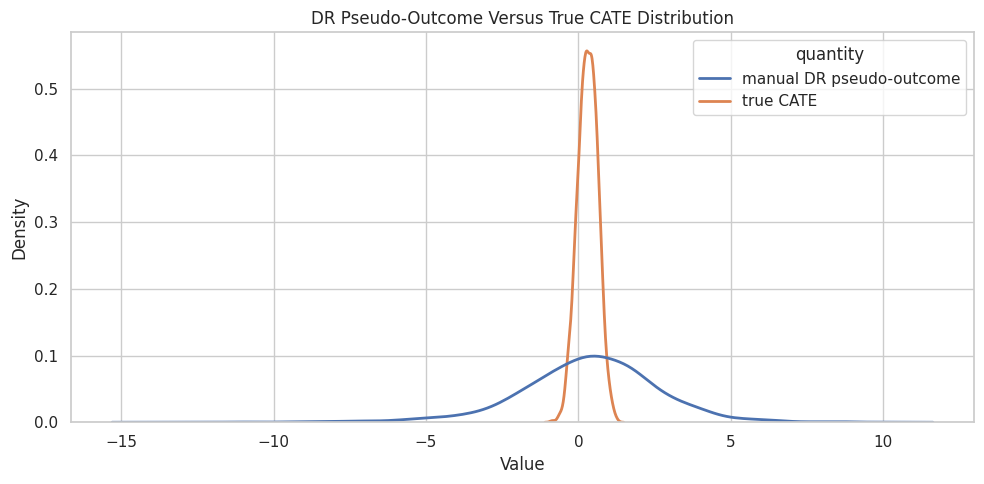

In [16]:
pseudo_plot_df = pd.DataFrame(
    {
        "value": np.concatenate([manual_dr_pseudo, true_cate_train]),
        "quantity": ["manual DR pseudo-outcome"] * len(manual_dr_pseudo) + ["true CATE"] * len(true_cate_train),
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=pseudo_plot_df, x="value", hue="quantity", fill=False, linewidth=2, ax=ax)
ax.set_title("DR Pseudo-Outcome Versus True CATE Distribution")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_dr_pseudo_outcome_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: pseudo-outcomes are not the same as individual true effects. They are noisy training targets whose conditional expectation is used to learn CATE.

## Manual DR Final CATE Model

Now we fit a final model that predicts the manual DR pseudo-outcome from `X`. This mirrors the DRLearner structure in a transparent way.

In [17]:
manual_final_model = RandomForestRegressor(
    n_estimators=180,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
manual_final_model.fit(X_train, manual_dr_pseudo)
manual_dr_cate_test = manual_final_model.predict(X_test)

manual_dr_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": manual_dr_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": manual_dr_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, manual_dr_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, manual_dr_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(manual_dr_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

manual_dr_summary.to_csv(TABLE_DIR / "05_manual_dr_final_model_summary.csv", index=False)
display(manual_dr_summary)

,metric,value
0,test_estimated_ate,0.3234
1,test_true_ate,0.2884
2,test_ate_error,0.0350
3,test_cate_rmse,0.4536
4,test_cate_correlation,0.5480
5,test_cate_spearman,0.5109


What this shows: smoothing the noisy DR pseudo-outcome over `X` creates useful CATE estimates. EconML `DRLearner` automates this workflow and handles the nuisance/final-stage plumbing.

## T-Learner Baseline

A T-learner fits separate outcome models for treated and untreated rows, then subtracts predicted control outcome from predicted treated outcome. It uses outcome regression but does not add the inverse-propensity correction term used by DR pseudo-outcomes.

This makes it a useful baseline for understanding what DRLearner adds.

In [18]:
t_learner_features = all_observed_covariates

t_model_control = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1)
t_model_treated = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1)

t_model_control.fit(train_df.loc[train_df["treatment"].eq(0), t_learner_features], train_df.loc[train_df["treatment"].eq(0), "outcome"])
t_model_treated.fit(train_df.loc[train_df["treatment"].eq(1), t_learner_features], train_df.loc[train_df["treatment"].eq(1), "outcome"])

t_learner_cate_test = (
    t_model_treated.predict(test_df[t_learner_features])
    - t_model_control.predict(test_df[t_learner_features])
)

t_learner_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": t_learner_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": t_learner_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, t_learner_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, t_learner_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(t_learner_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

t_learner_summary.to_csv(TABLE_DIR / "05_t_learner_baseline_summary.csv", index=False)
display(t_learner_summary)

,metric,value
0,test_estimated_ate,0.4053
1,test_true_ate,0.2884
2,test_ate_error,0.1169
3,test_cate_rmse,0.5428
4,test_cate_correlation,0.4742
5,test_cate_spearman,0.4551


What this shows: the T-learner is a strong outcome-regression baseline. DRLearner should be compared against it because doubly robust estimation is most meaningful when we see what the outcome-only route can already do.

## Fit EconML DRLearner With A Linear Final Model

This first `DRLearner` uses flexible nuisance models but a linear final CATE model. That makes the final CATE surface easier to explain, but less flexible.

In [19]:
if not ECONML_AVAILABLE:
    raise ImportError(f"EconML is not available in this environment: {ECONML_VERSION}")

dr_linear = DRLearner(
    model_regression=RandomForestRegressor(n_estimators=160, min_samples_leaf=20, random_state=RANDOM_SEED + 3, n_jobs=-1),
    model_propensity=RandomForestClassifier(n_estimators=160, min_samples_leaf=20, random_state=RANDOM_SEED + 3, n_jobs=-1),
    model_final=LinearRegression(),
    cv=5,
    min_propensity=0.03,
    random_state=RANDOM_SEED,
)
dr_linear.fit(Y_train, T_train, X=X_train, W=W_train, inference=None)
dr_linear_cate_test = np.ravel(dr_linear.effect(X_test))

dr_linear_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": dr_linear_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": dr_linear_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, dr_linear_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, dr_linear_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(dr_linear_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

dr_linear_summary.to_csv(TABLE_DIR / "05_drlearner_linear_summary.csv", index=False)
display(dr_linear_summary)

,metric,value
0,test_estimated_ate,0.2582
1,test_true_ate,0.2884
2,test_ate_error,-0.0302
3,test_cate_rmse,0.1609
4,test_cate_correlation,0.8735
5,test_cate_spearman,0.8596


What this shows: DRLearner can use a simple final model when the CATE story needs to be compact. The tradeoff is that nonlinear effect patterns may be compressed.

## Fit EconML DRLearner With A Flexible Final Model

This second `DRLearner` uses the same doubly robust nuisance logic but a random-forest final model. That final model can learn nonlinear CATE patterns from the pseudo-outcome.

In [20]:
dr_forest = DRLearner(
    model_regression=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 4, n_jobs=-1),
    model_propensity=RandomForestClassifier(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 4, n_jobs=-1),
    model_final=RandomForestRegressor(n_estimators=220, min_samples_leaf=20, random_state=RANDOM_SEED + 5, n_jobs=-1),
    cv=5,
    min_propensity=0.03,
    random_state=RANDOM_SEED,
)
dr_forest.fit(Y_train, T_train, X=X_train, W=W_train, inference=None)
dr_forest_cate_test = np.ravel(dr_forest.effect(X_test))

dr_forest_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": dr_forest_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": dr_forest_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, dr_forest_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, dr_forest_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(dr_forest_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

dr_forest_summary.to_csv(TABLE_DIR / "05_drlearner_forest_summary.csv", index=False)
display(dr_forest_summary)

,metric,value
0,test_estimated_ate,0.2671
1,test_true_ate,0.2884
2,test_ate_error,-0.0213
3,test_cate_rmse,0.3983
4,test_cate_correlation,0.5606
5,test_cate_spearman,0.5375


What this shows: the flexible final model is closer to the usual reason for trying DRLearner on heterogeneous effects. The pseudo-outcome supplies the target, and the final model supplies the CATE shape.

## Optional LinearDML Baseline

A `LinearDML` baseline gives us a bridge back to the earlier DML notebooks. It is not the star of this lesson, but it helps compare residualization-based and pseudo-outcome-based workflows.

In [21]:
linear_dml_baseline = LinearDML(
    model_y=RandomForestRegressor(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED + 6, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED + 6, n_jobs=-1),
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
)
linear_dml_baseline.fit(Y_train, T_train, X=X_train, W=W_train, inference=None)
linear_dml_cate_test = np.ravel(linear_dml_baseline.effect(X_test))

linear_dml_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": linear_dml_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": linear_dml_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, linear_dml_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, linear_dml_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(linear_dml_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

linear_dml_summary.to_csv(TABLE_DIR / "05_lineardml_baseline_summary.csv", index=False)
display(linear_dml_summary)

,metric,value
0,test_estimated_ate,0.2674
1,test_true_ate,0.2884
2,test_ate_error,-0.0210
3,test_cate_rmse,0.1580
4,test_cate_correlation,0.8852
5,test_cate_spearman,0.8720


What this shows: DML and DR workflows can both estimate CATE, but they construct the final learning target differently. Comparing them helps build estimator intuition.

## Estimator Comparison

The next table compares raw difference, T-learner, manual DR, EconML DRLearner variants, and LinearDML on the same test set.

In [22]:
def model_metrics(method, cate_estimate):
    return {
        "method": method,
        "estimated_ate_on_test_population": float(np.mean(cate_estimate)),
        "true_ate_on_test_population": float(true_cate_test.mean()),
        "ate_error": float(np.mean(cate_estimate) - true_cate_test.mean()),
        "cate_rmse": float(np.sqrt(mean_squared_error(true_cate_test, cate_estimate))),
        "cate_correlation": float(np.corrcoef(true_cate_test, cate_estimate)[0, 1]),
        "cate_spearman": float(pd.Series(cate_estimate).corr(pd.Series(true_cate_test), method="spearman")),
    }

comparison_rows = [
    {
        "method": "raw treated-control difference",
        "estimated_ate_on_test_population": raw_difference,
        "true_ate_on_test_population": true_cate_test.mean(),
        "ate_error": raw_difference - true_cate_test.mean(),
        "cate_rmse": np.nan,
        "cate_correlation": np.nan,
        "cate_spearman": np.nan,
    },
    model_metrics("T-learner outcome-only baseline", t_learner_cate_test),
    model_metrics("manual DR pseudo-outcome forest", manual_dr_cate_test),
    model_metrics("EconML DRLearner linear final", dr_linear_cate_test),
    model_metrics("EconML DRLearner forest final", dr_forest_cate_test),
    model_metrics("LinearDML baseline", linear_dml_cate_test),
]

comparison_table = pd.DataFrame(comparison_rows)
comparison_table.to_csv(TABLE_DIR / "05_estimator_comparison.csv", index=False)
display(comparison_table)

,method,estimated_ate_on_test_population,true_ate_on_test_population,ate_error,cate_rmse,cate_correlation,cate_spearman
0,raw treated-control difference,0.9791,0.2884,0.6908,NaN,NaN,NaN
1,T-learner outcome-only baseline,0.4053,0.2884,0.1169,0.5428,0.4742,0.4551
2,manual DR pseudo-outcome forest,0.3234,0.2884,0.0350,0.4536,0.5480,0.5109
3,EconML DRLearner linear final,0.2582,0.2884,-0.0302,0.1609,0.8735,0.8596
4,EconML DRLearner forest final,0.2671,0.2884,-0.0213,0.3983,0.5606,0.5375
5,LinearDML baseline,0.2674,0.2884,-0.0210,0.1580,0.8852,0.8720


What this shows: the DRLearner variants should be evaluated on both average-effect error and CATE ranking quality. The best estimator depends on whether the task needs an average, a ranking, or a readable segment story.

## CATE Recovery Scatter

The scatter plot compares estimated CATE values with known true CATE values on the test set.

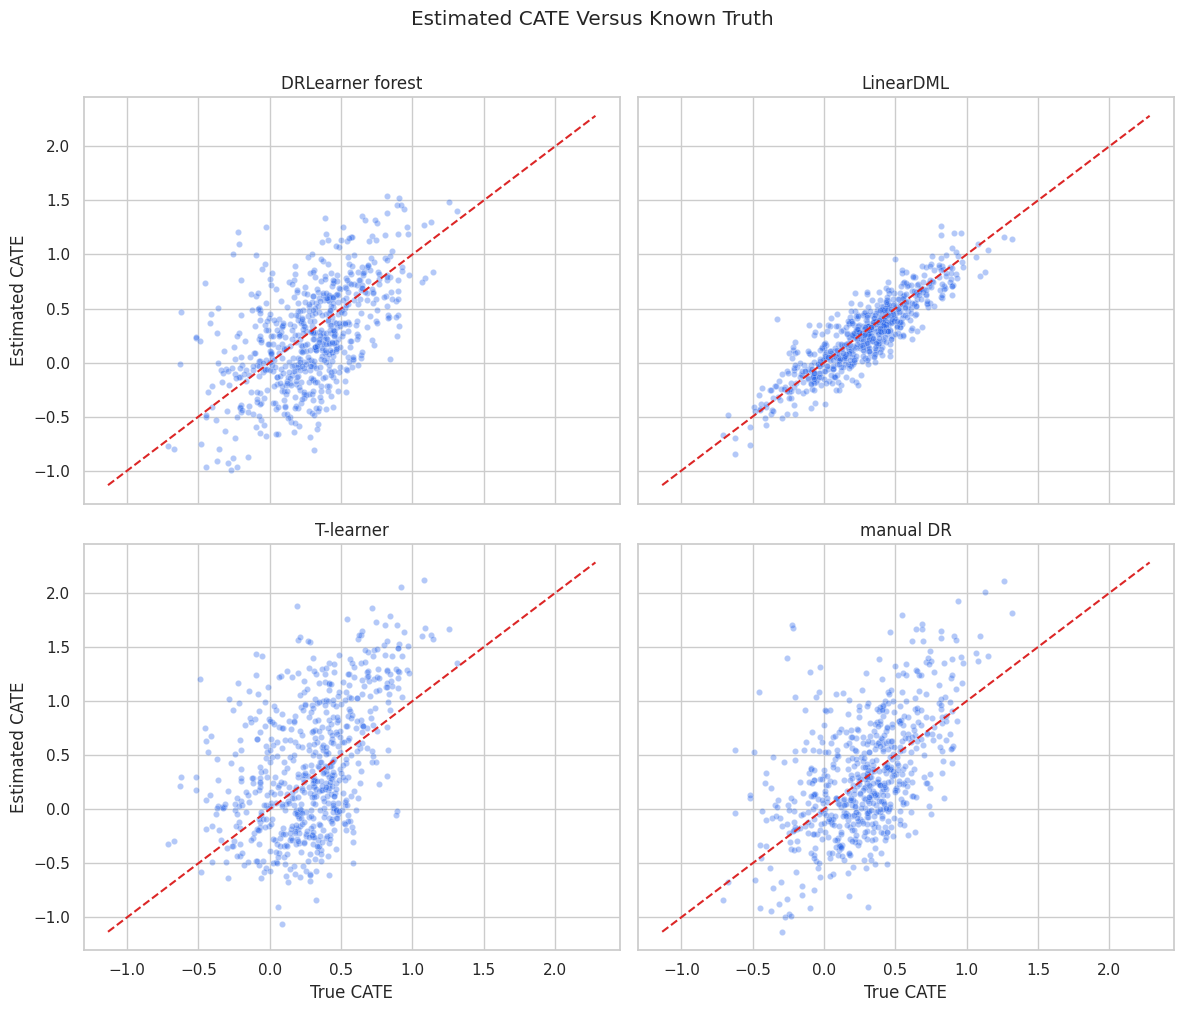

In [23]:
cate_plot_df = pd.concat(
    [
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": t_learner_cate_test, "estimator": "T-learner"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": manual_dr_cate_test, "estimator": "manual DR"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": dr_forest_cate_test, "estimator": "DRLearner forest"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": linear_dml_cate_test, "estimator": "LinearDML"}),
    ],
    ignore_index=True,
)
limits = [
    min(cate_plot_df["true_cate"].min(), cate_plot_df["estimated_cate"].min()),
    max(cate_plot_df["true_cate"].max(), cate_plot_df["estimated_cate"].max()),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()
for ax, (estimator_name, estimator_df) in zip(axes, cate_plot_df.groupby("estimator")):
    sample_df = estimator_df.sample(n=min(650, len(estimator_df)), random_state=RANDOM_SEED)
    sns.scatterplot(data=sample_df, x="true_cate", y="estimated_cate", alpha=0.35, s=20, color="#2563eb", ax=ax)
    ax.plot(limits, limits, color="#dc2626", linestyle="--", linewidth=1.5)
    ax.set_title(estimator_name)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")

plt.suptitle("Estimated CATE Versus Known Truth", y=1.01)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_cate_recovery_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: each estimator makes a different bias-variance tradeoff. DRLearner's final model should smooth a noisy pseudo-outcome without erasing important CATE structure.

## DRLearner Final-Model Feature Importance

For the forest-final DRLearner, we can inspect the fitted final random forest's feature importance. This tells us which `X` features were most useful for predicting the DR pseudo-outcome.

In [24]:
dr_final_model = dr_forest.ortho_learner_model_final_.models_cate[0]
if not hasattr(dr_final_model, "feature_importances_"):
    raise AttributeError("The fitted DRLearner final model does not expose feature_importances_.")

dr_feature_importance = pd.DataFrame(
    {
        "feature": effect_modifier_cols,
        "importance": dr_final_model.feature_importances_,
        "true_cate_driver": [col in true_driver_cols for col in effect_modifier_cols],
    }
).sort_values("importance", ascending=False)

dr_feature_importance.to_csv(TABLE_DIR / "05_drlearner_final_feature_importance.csv", index=False)
display(dr_feature_importance)

,feature,importance,true_cate_driver
2,friction_score,0.1791,True
0,baseline_need,0.1675,True
3,content_affinity,0.1670,True
1,prior_engagement,0.1260,True
5,trust_score,0.1247,False
4,price_sensitivity,0.1213,True
6,recency_gap,0.1056,False
7,region_risk,0.0080,True
8,high_need_segment,0.0007,True


What this shows: feature importance explains the fitted final CATE model, not the causal design. A feature can be important in the final model only if it is included in `X`.

## Feature Importance Plot

The plot makes the final-model importance ranking easier to scan.

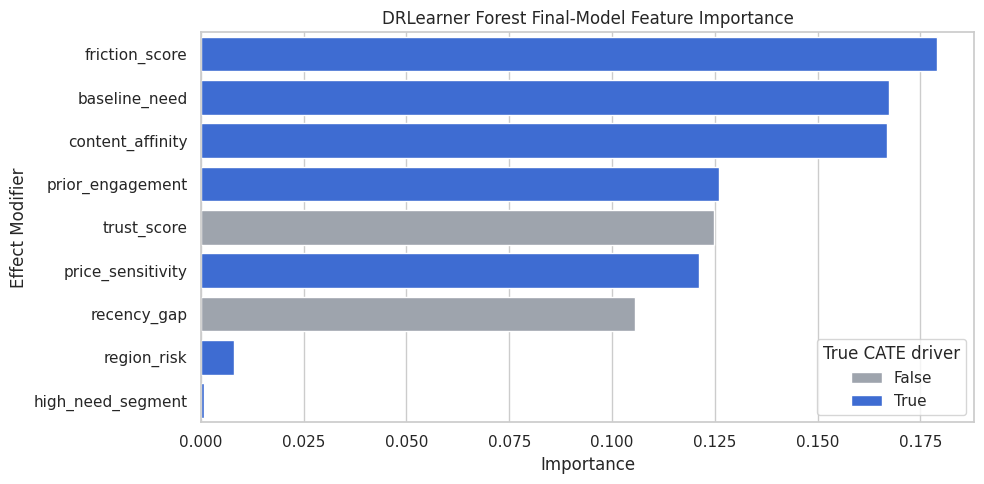

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=dr_feature_importance,
    x="importance",
    y="feature",
    hue="true_cate_driver",
    dodge=False,
    palette={True: "#2563eb", False: "#9ca3af"},
    ax=ax,
)
ax.set_title("DRLearner Forest Final-Model Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Effect Modifier")
ax.legend(title="True CATE driver")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_drlearner_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the feature-importance view turns the final DRLearner model into a readable diagnostic. It should be paired with CATE recovery, calibration, and segment checks.

## CATE Decile Calibration

CATE models are often used for ranking units. The next table groups test rows by predicted CATE decile and compares estimated versus true average CATE.

In [26]:
test_results = test_df.assign(
    t_learner_cate=t_learner_cate_test,
    manual_dr_cate=manual_dr_cate_test,
    dr_linear_cate=dr_linear_cate_test,
    dr_forest_cate=dr_forest_cate_test,
    linear_dml_cate=linear_dml_cate_test,
)

calibration_frames = []
for estimator_name, score_col in [
    ("T-learner", "t_learner_cate"),
    ("manual DR", "manual_dr_cate"),
    ("DRLearner forest", "dr_forest_cate"),
    ("LinearDML", "linear_dml_cate"),
]:
    temp = test_results.copy()
    temp["cate_decile"] = pd.qcut(temp[score_col], q=10, labels=False, duplicates="drop") + 1
    deciles = (
        temp.groupby("cate_decile", observed=True)
        .agg(
            rows=("outcome", "size"),
            estimated_cate=(score_col, "mean"),
            true_cate=("true_cate", "mean"),
            treatment_rate=("treatment", "mean"),
            propensity_mean=("propensity", "mean"),
        )
        .reset_index()
    )
    deciles["estimator"] = estimator_name
    calibration_frames.append(deciles)

cate_decile_calibration = pd.concat(calibration_frames, ignore_index=True)
cate_decile_calibration.to_csv(TABLE_DIR / "05_cate_decile_calibration.csv", index=False)
display(cate_decile_calibration)

,cate_decile,rows,estimated_cate,true_cate,treatment_rate,propensity_mean,estimator
0,1,112,-0.4971,0.0993,0.4107,0.3752,T-learner
1,2,112,-0.2412,0.1297,0.4286,0.4278,T-learner
2,3,112,-0.0747,0.2235,0.3839,0.4198,T-learner
3,4,112,0.0839,0.1395,0.4643,0.4773,T-learner
4,5,112,0.2457,0.2386,0.4464,0.4807,T-learner
5,6,112,0.4304,0.3077,0.5000,0.4897,T-learner
6,7,112,0.6473,0.2907,0.4464,0.4526,T-learner
7,8,112,0.8599,0.3360,0.4732,0.4545,T-learner
8,9,112,1.1110,0.4604,0.6696,0.6203,T-learner
9,10,112,1.4874,0.6584,0.6518,0.6702,T-learner


What this shows: higher predicted deciles should have higher true CATE if the model ranks well. This is one of the most useful truth-known checks for treatment targeting.

## CATE Decile Calibration Plot

The plot compares estimated and true average CATE by predicted-effect decile for selected estimators.

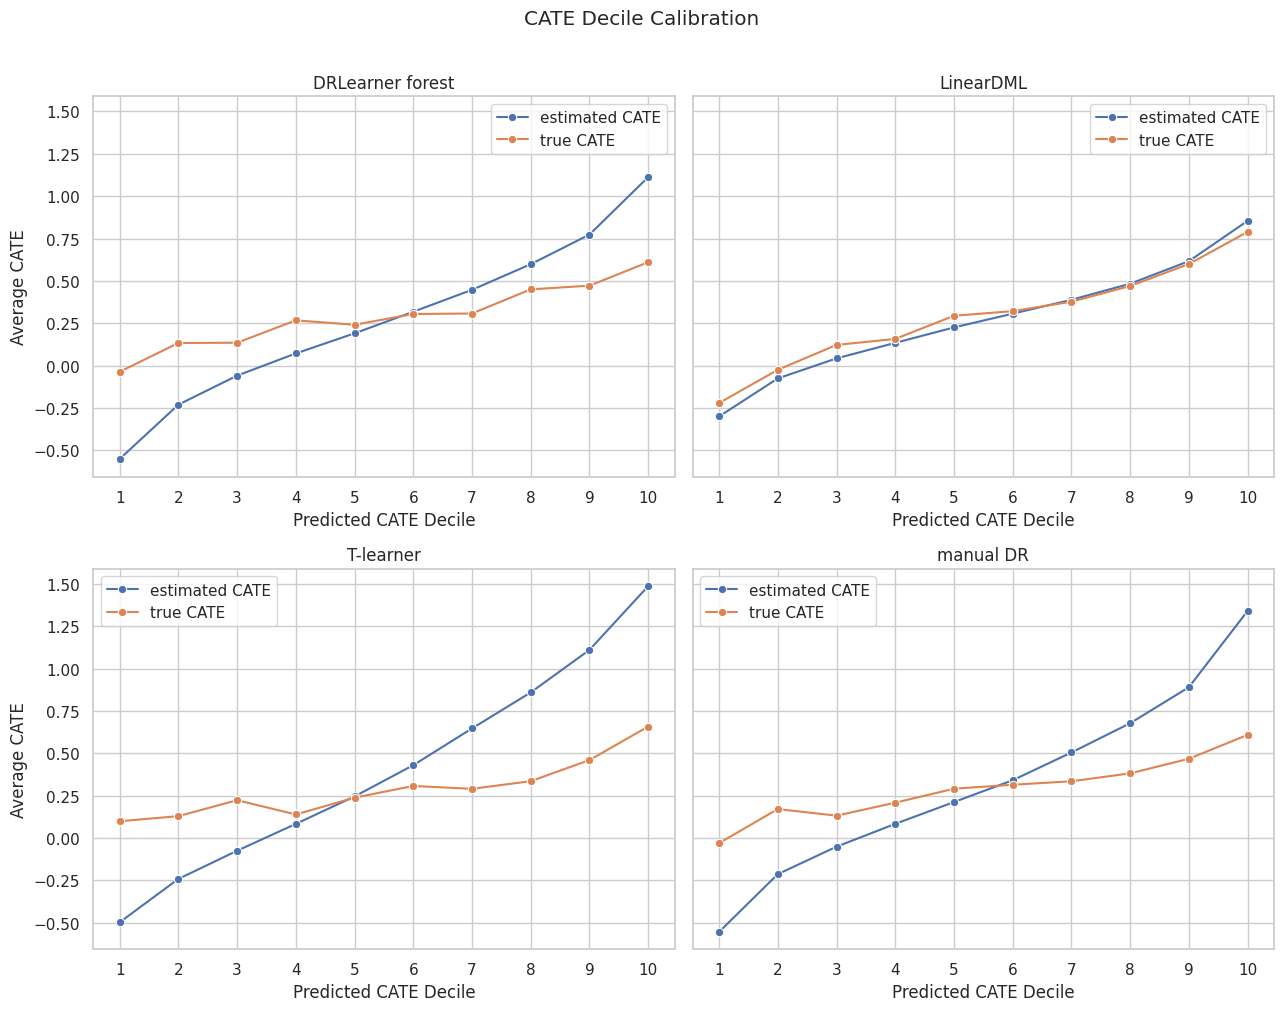

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True)
axes = axes.ravel()
for ax, (estimator_name, estimator_df) in zip(axes, cate_decile_calibration.groupby("estimator")):
    sns.lineplot(data=estimator_df, x="cate_decile", y="estimated_cate", marker="o", label="estimated CATE", ax=ax)
    sns.lineplot(data=estimator_df, x="cate_decile", y="true_cate", marker="o", label="true CATE", ax=ax)
    ax.set_title(estimator_name)
    ax.set_xlabel("Predicted CATE Decile")
    ax.set_ylabel("Average CATE")
    ax.set_xticks(sorted(estimator_df["cate_decile"].unique()))

plt.suptitle("CATE Decile Calibration", y=1.01)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_cate_decile_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: decile calibration connects estimation to action. A model can be useful for targeting even if individual CATE point estimates are noisy.

## Segment-Level Recovery

Segment summaries make CATE estimates easier to communicate. Here we summarize by high-need segment and region risk.

In [28]:
segment_summary = (
    test_results.groupby(["high_need_segment", "region_risk"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        t_learner_cate=("t_learner_cate", "mean"),
        manual_dr_cate=("manual_dr_cate", "mean"),
        dr_forest_cate=("dr_forest_cate", "mean"),
        linear_dml_cate=("linear_dml_cate", "mean"),
        treatment_rate=("treatment", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)
segment_summary["dr_forest_error"] = segment_summary["dr_forest_cate"] - segment_summary["true_cate"]
segment_summary["t_learner_error"] = segment_summary["t_learner_cate"] - segment_summary["true_cate"]

segment_summary.to_csv(TABLE_DIR / "05_segment_cate_recovery.csv", index=False)
display(segment_summary)

,high_need_segment,region_risk,rows,true_cate,t_learner_cate,manual_dr_cate,dr_forest_cate,linear_dml_cate,treatment_rate,propensity_mean,dr_forest_error,t_learner_error
0,0,0,527,0.2910,0.2543,0.2291,0.2139,0.2464,0.3643,0.3612,-0.0772,-0.0367
1,0,1,262,0.1221,0.3284,0.3133,0.2866,0.1610,0.3740,0.4027,0.1645,0.2063
2,1,0,205,0.4771,0.6927,0.4643,0.3234,0.4032,0.7512,0.7300,-0.1537,0.2156
3,1,1,126,0.3159,0.7291,0.5095,0.3572,0.3549,0.8095,0.7915,0.0413,0.4132


What this shows: segment summaries reveal whether the learner recovers broad subgroup patterns, not just overall ranking. This is often the most readable way to explain heterogeneous effects.

## Segment Recovery Plot

This plot compares true and estimated segment-level effects.

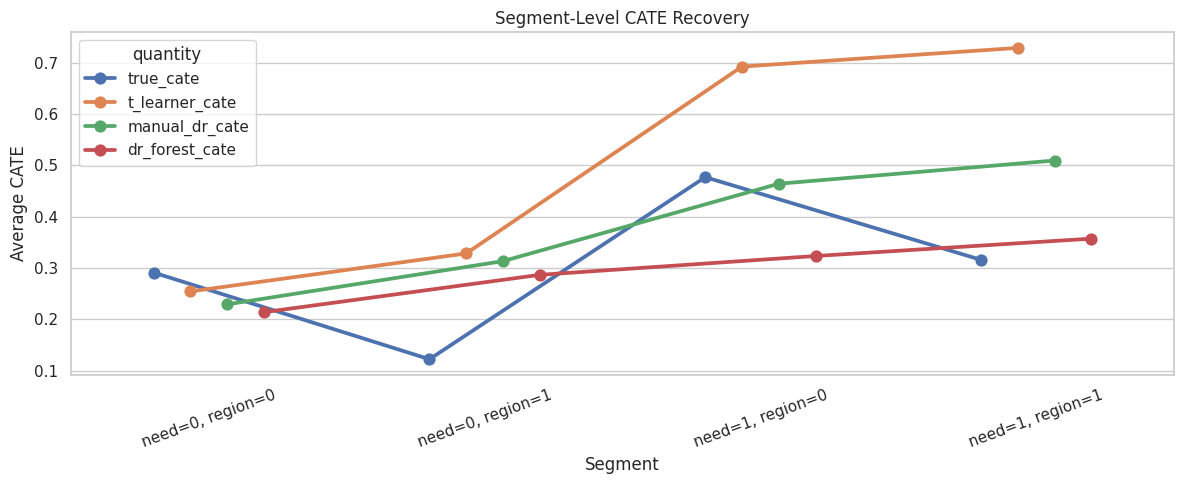

In [29]:
segment_plot_df = segment_summary.melt(
    id_vars=["high_need_segment", "region_risk", "rows"],
    value_vars=["true_cate", "t_learner_cate", "manual_dr_cate", "dr_forest_cate"],
    var_name="quantity",
    value_name="average_cate",
)
segment_plot_df["segment"] = (
    "need=" + segment_plot_df["high_need_segment"].astype(str)
    + ", region=" + segment_plot_df["region_risk"].astype(str)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.pointplot(
    data=segment_plot_df,
    x="segment",
    y="average_cate",
    hue="quantity",
    dodge=0.40,
    errorbar=None,
    ax=ax,
)
ax.set_title("Segment-Level CATE Recovery")
ax.set_xlabel("Segment")
ax.set_ylabel("Average CATE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_segment_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: segment plots are useful because DR pseudo-outcomes themselves can be noisy. Segment aggregation makes the treatment-effect story easier to compare across methods.

## Propensity Weight Diagnostics

The DR correction terms include `1 / e` for treated rows and `1 / (1 - e)` for untreated rows. Large weights can create noisy pseudo-outcomes.

The next cell summarizes manual cross-fitted correction weights.

In [30]:
manual_weight = np.where(T_train == 1, 1 / e_hat_oof, 1 / (1 - e_hat_oof))
weight_summary = pd.DataFrame(
    [
        {"metric": "mean_weight", "value": manual_weight.mean()},
        {"metric": "median_weight", "value": np.median(manual_weight)},
        {"metric": "p90_weight", "value": np.quantile(manual_weight, 0.90)},
        {"metric": "p95_weight", "value": np.quantile(manual_weight, 0.95)},
        {"metric": "max_weight", "value": manual_weight.max()},
        {"metric": "share_weight_above_5", "value": (manual_weight > 5).mean()},
    ]
)

weight_summary.to_csv(TABLE_DIR / "05_manual_dr_weight_summary.csv", index=False)
display(weight_summary)

,metric,value
0,mean_weight,1.9052
1,median_weight,1.6248
2,p90_weight,2.9084
3,p95_weight,3.5049
4,max_weight,10.0023
5,share_weight_above_5,0.0139


What this shows: weight diagnostics help explain pseudo-outcome noise. Propensity clipping is a practical guardrail against extremely large correction terms.

## Weight Distribution Plot

This plot shows the distribution of inverse-propensity correction weights used in the manual pseudo-outcome.

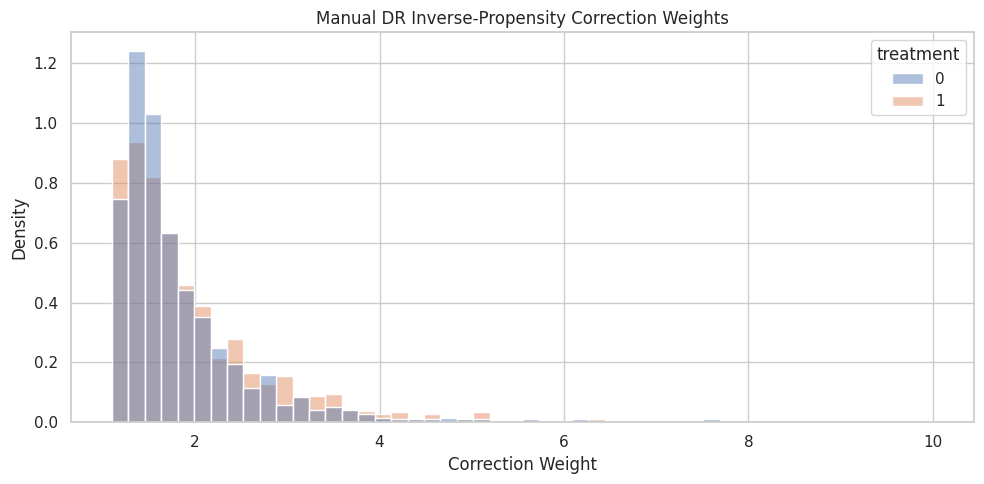

In [31]:
weight_plot_df = pd.DataFrame({"manual_dr_weight": manual_weight, "treatment": T_train})

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=weight_plot_df,
    x="manual_dr_weight",
    hue="treatment",
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("Manual DR Inverse-Propensity Correction Weights")
ax.set_xlabel("Correction Weight")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_manual_dr_weight_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: most correction weights are moderate, so the pseudo-outcome is not dominated by a handful of extreme-weight rows. That supports the stability of this teaching example.

## Targeting Comparison

A common use for CATE estimates is selecting the top fraction of units for treatment. The next cell compares random targeting, T-learner targeting, manual DR targeting, DRLearner targeting, and an oracle benchmark.

In [32]:
targeting_fraction = 0.20
k = int(np.ceil(targeting_fraction * len(test_results)))
random_selected = test_results.sample(n=k, random_state=RANDOM_SEED).index
t_selected = test_results.sort_values("t_learner_cate", ascending=False).head(k).index
manual_dr_selected = test_results.sort_values("manual_dr_cate", ascending=False).head(k).index
dr_forest_selected = test_results.sort_values("dr_forest_cate", ascending=False).head(k).index
linear_dml_selected = test_results.sort_values("linear_dml_cate", ascending=False).head(k).index
oracle_selected = test_results.sort_values("true_cate", ascending=False).head(k).index

targeting_rows = []
for rule_name, selected_index in [
    ("random 20 percent", random_selected),
    ("top 20 percent by T-learner", t_selected),
    ("top 20 percent by manual DR", manual_dr_selected),
    ("top 20 percent by DRLearner forest", dr_forest_selected),
    ("top 20 percent by LinearDML", linear_dml_selected),
    ("oracle top 20 percent by true CATE", oracle_selected),
]:
    selected = test_results.loc[selected_index]
    targeting_rows.append(
        {
            "targeting_rule": rule_name,
            "selected_rows": len(selected),
            "average_true_cate_in_selected_group": selected["true_cate"].mean(),
            "average_dr_forest_cate": selected["dr_forest_cate"].mean(),
            "share_high_need_segment": selected["high_need_segment"].mean(),
            "average_propensity": selected["propensity"].mean(),
        }
    )

targeting_summary = pd.DataFrame(targeting_rows)
targeting_summary["gain_vs_random_true_cate"] = (
    targeting_summary["average_true_cate_in_selected_group"]
    - targeting_summary.loc[targeting_summary["targeting_rule"].eq("random 20 percent"), "average_true_cate_in_selected_group"].iloc[0]
)

targeting_summary.to_csv(TABLE_DIR / "05_targeting_summary.csv", index=False)
display(targeting_summary)

,targeting_rule,selected_rows,average_true_cate_in_selected_group,average_dr_forest_cate,share_high_need_segment,average_propensity,gain_vs_random_true_cate
0,random 20 percent,224,0.2544,0.2023,0.2812,0.4693,0.0000
1,top 20 percent by T-learner,224,0.5594,0.7208,0.5893,0.6453,0.3050
2,top 20 percent by manual DR,224,0.5387,0.8800,0.4152,0.5760,0.2843
3,top 20 percent by DRLearner forest,224,0.5410,0.9431,0.3393,0.5310,0.2866
4,top 20 percent by LinearDML,224,0.6943,0.6981,0.4464,0.5997,0.4399
5,oracle top 20 percent by true CATE,224,0.7393,0.7114,0.5134,0.6441,0.4849


What this shows: CATE models matter operationally when they improve the selected group's true benefit over random targeting. The oracle row is an unattainable upper benchmark available only in simulation.

## Targeting Plot

This plot compares true benefit among selected test rows under each targeting rule.

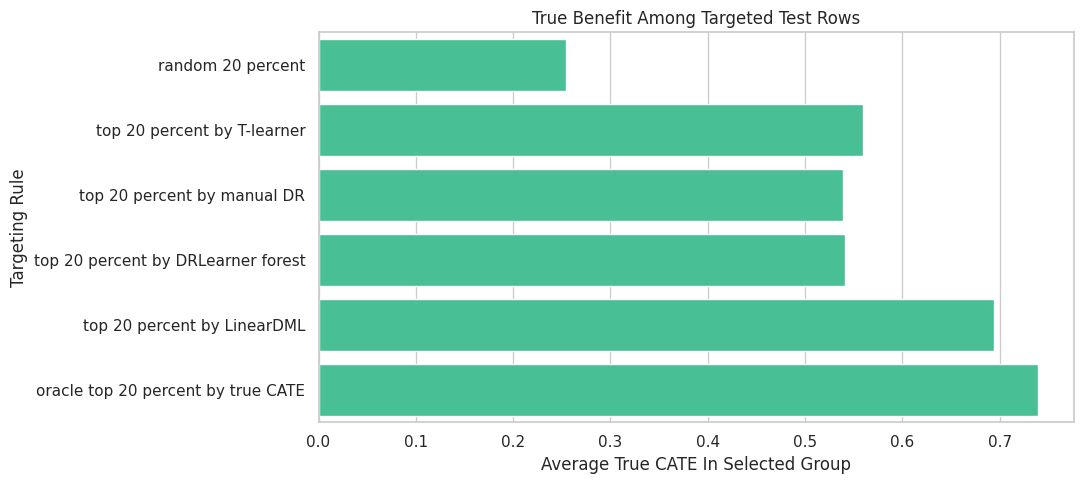

In [33]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=targeting_summary,
    x="average_true_cate_in_selected_group",
    y="targeting_rule",
    color="#34d399",
    ax=ax,
)
ax.set_title("True Benefit Among Targeted Test Rows")
ax.set_xlabel("Average True CATE In Selected Group")
ax.set_ylabel("Targeting Rule")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_targeting_summary.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: model comparison should be tied to the decision. A model with slightly worse RMSE can still be useful if it ranks the highest-benefit units well.

## Practical DRLearner Guidance

This table summarizes when DRLearner is a good estimator to try and what to watch.

In [34]:
practical_guidance = pd.DataFrame(
    [
        {
            "situation": "Binary treatment with observed confounding",
            "why DRLearner helps": "It combines outcome regression and propensity correction in a CATE pseudo-outcome.",
            "watchout": "Both nuisance routes still need credible pre-treatment covariates and overlap.",
        },
        {
            "situation": "Outcome models are strong but treatment assignment is uneven",
            "why DRLearner helps": "Outcome regression carries much of the signal while propensity correction reduces assignment bias.",
            "watchout": "Extreme propensity values can still inflate pseudo-outcome noise.",
        },
        {
            "situation": "Treatment targeting is the main goal",
            "why DRLearner helps": "A flexible final model can learn rankings from DR pseudo-outcomes.",
            "watchout": "Evaluate ranking and policy value, not only average effect.",
        },
        {
            "situation": "A very readable CATE story is required",
            "why DRLearner helps": "A linear final model can make the final CATE surface compact.",
            "watchout": "The final model may miss nonlinear heterogeneity.",
        },
    ]
)

practical_guidance.to_csv(TABLE_DIR / "05_practical_guidance.csv", index=False)
display(practical_guidance)

,situation,why DRLearner helps,watchout
0,Binary treatment with observed confounding,It combines outcome regression and propensity ...,Both nuisance routes still need credible pre-t...
1,Outcome models are strong but treatment assign...,Outcome regression carries much of the signal ...,Extreme propensity values can still inflate ps...
2,Treatment targeting is the main goal,A flexible final model can learn rankings from...,"Evaluate ranking and policy value, not only av..."
3,A very readable CATE story is required,A linear final model can make the final CATE s...,The final model may miss nonlinear heterogeneity.


What this shows: DRLearner is a flexible framework. The analyst chooses nuisance models and the final CATE model based on the causal question, data support, and reporting needs.

## DRLearner Checklist

Before presenting DRLearner results, it is worth checking the items below.

In [35]:
dr_checklist = pd.DataFrame(
    [
        {"check": "Treatment and outcome are clearly defined", "why_it_matters": "DRLearner estimates the effect of a specific intervention."},
        {"check": "All X and W variables are pre-treatment", "why_it_matters": "Post-treatment variables can distort the estimand."},
        {"check": "Important confounders are included", "why_it_matters": "Double robustness does not fix omitted confounding."},
        {"check": "Overlap is adequate", "why_it_matters": "Inverse-propensity corrections become unstable near zero or one."},
        {"check": "Propensity model quality is inspected", "why_it_matters": "Bad propensity estimates can create poor correction terms."},
        {"check": "Outcome models by treatment arm are inspected", "why_it_matters": "The pseudo-outcome relies heavily on potential-outcome predictions."},
        {"check": "Pseudo-outcome tails and weights are checked", "why_it_matters": "Large correction weights can dominate the final model."},
        {"check": "Final CATE model is appropriate", "why_it_matters": "A linear final model and a forest final model tell different stories."},
        {"check": "CATE ranking is validated where possible", "why_it_matters": "Treatment targeting depends on ranking, not only ATE accuracy."},
    ]
)

dr_checklist.to_csv(TABLE_DIR / "05_drlearner_checklist.csv", index=False)
display(dr_checklist)

,check,why_it_matters
0,Treatment and outcome are clearly defined,DRLearner estimates the effect of a specific i...
1,All X and W variables are pre-treatment,Post-treatment variables can distort the estim...
2,Important confounders are included,Double robustness does not fix omitted confoun...
3,Overlap is adequate,Inverse-propensity corrections become unstable...
4,Propensity model quality is inspected,Bad propensity estimates can create poor corre...
5,Outcome models by treatment arm are inspected,The pseudo-outcome relies heavily on potential...
6,Pseudo-outcome tails and weights are checked,Large correction weights can dominate the fina...
7,Final CATE model is appropriate,A linear final model and a forest final model ...
8,CATE ranking is validated where possible,"Treatment targeting depends on ranking, not on..."


What this shows: DRLearner is not a shortcut around causal design. It is a powerful estimator once the treatment, outcome, covariates, and support are all defensible.

## Summary

This notebook introduced `DRLearner` and doubly robust CATE estimation.

The main takeaways are:

- DRLearner uses outcome nuisance models, a propensity nuisance model, and a final CATE model;
- the doubly robust pseudo-outcome combines `m1 - m0` with inverse-propensity residual corrections;
- double robustness means the estimator has two routes to credibility, but it still needs identification and overlap;
- pseudo-outcomes are noisy training targets, so final-stage smoothing matters;
- propensity clipping and weight diagnostics are practical stability checks;
- DRLearner can use a readable linear final model or a flexible forest final model;
- CATE estimates should be evaluated through average error, ranking, segment summaries, and targeting performance.

The next tutorial can cover S-learner, T-learner, X-learner, and related meta-learners, which provide a broader family of outcome-model-based CATE strategies.